<a href="https://colab.research.google.com/github/sg-56/DLT_Workshop/blob/main/Workshop_2_0_Part2_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework

Write a python script that will load data from the Jikan API (Unofficial MyAnimeList API) into DuckDB using dlt and complete the tasks.

Jikan API URL: https://api.jikan.moe/v4

Docs: https://docs.api.jikan.moe/#section/Information



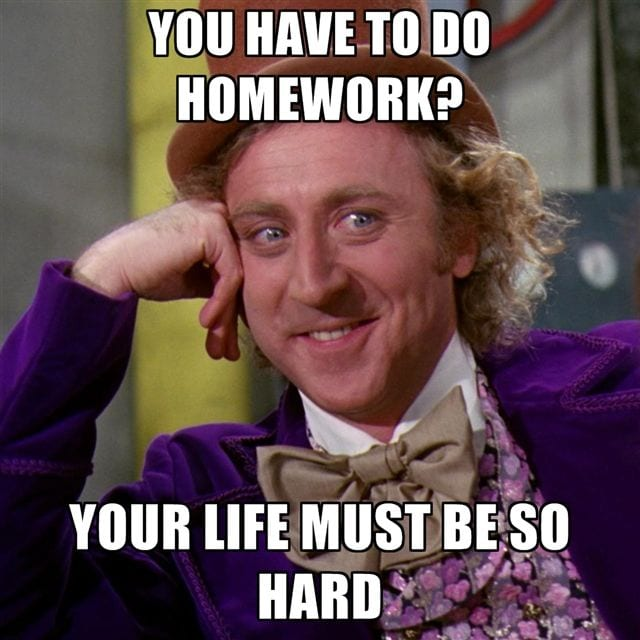

# Install dlt with duckdb extention

In [1]:
%%capture
!pip install dlt[duckdb]

# Task 1: Backfill your data & Retry on failures

Reuse your incremental pipeline from Part 1.

- [Backfill](https://dlthub.com/docs/general-usage/incremental-loading#using-end_value-for-backfill) animes released within the last 6 months (from March 1st until Septemper 1st).

- This API has [Rate Limits](https://docs.api.jikan.moe/#section/Information/Rate-Limiting). The pipeline can be retried, as covered in the workshop, and [demo](https://colab.research.google.com/drive/1wqeIv0nD6S9r8ImJEbZ_PYBgeE3C3kMO).

Read more about [incremental loading](https://dlthub.com/docs/general-usage/incremental-loading).


In [2]:
import time
import dlt
import requests

def pagination(url,params):
  while True:
    response = requests.get(f"{url}",params=params)
    if  not response:
      break
    data = response.json()["data"]
    yield data
    params['page'] += 1

@dlt.resource(table_name="anime", write_disposition={"disposition": "merge"}, primary_key="mal_id")
def get_anime(
    aired__from=dlt.sources.incremental("aired.from",initial_value="2024-03-01T00:00:00Z",
            end_value="2024-09-01T00:00:00Z")):
    print(aired__from.last_value)
    url = 'https://api.jikan.moe/v4/anime'
    params = {
         "order_by": "start_date",
          "start_date": "2024-03-01",
          'page':1
    }
    yield pagination(url, params)

pipeline = dlt.pipeline(
    pipeline_name='anime_pipeline',
    destination='duckdb',
    dataset_name='anime_data',
    dev_mode=True,
)

load_info = pipeline.run(get_anime())
print(load_info)
print(pipeline.last_trace.last_normalize_info)
#assert_load_info(load_info)

load_info = pipeline.run(get_anime())
print(load_info)
print(pipeline.last_trace.last_normalize_info)
#assert_load_info(load_info, expected_load_packages=0)

2024-03-01T00:00:00Z
Pipeline anime_pipeline load step completed in 2.89 seconds
1 load package(s) were loaded to destination duckdb and into dataset anime_data_20241012033546
The duckdb destination used duckdb:////content/anime_pipeline.duckdb location to store data
Load package 1728747346.4404774 is LOADED and contains no failed jobs
Normalized data for the following tables:
- _dlt_pipeline_state: 1 row(s)
- anime: 121 row(s)
- anime__titles: 389 row(s)
- anime__producers: 351 row(s)
- anime__studios: 101 row(s)
- anime__themes: 126 row(s)
- anime__demographics: 32 row(s)
- anime__genres: 206 row(s)
- anime__title_synonyms: 84 row(s)
- anime__licensors: 2 row(s)

Load package 1728747346.4404774 is NORMALIZED and NOT YET LOADED to the destination and contains no failed jobs
2024-03-01T00:00:00Z
Pipeline anime_pipeline load step completed in 2.29 seconds
1 load package(s) were loaded to destination duckdb and into dataset anime_data_20241012033546
The duckdb destination used duckdb:///

Run the code below and

## Answer the Questions:
**1.1.**  How many columns has `anime` table?

In [3]:
import duckdb
from google.colab import data_table
data_table.enable_dataframe_formatter()

conn = duckdb.connect(f"{pipeline.pipeline_name}.duckdb")
conn.sql(f"SET search_path = '{pipeline.dataset_name}'")
print(len(conn.sql("select * from anime").df().columns))
conn.sql("select * from anime").df()

52


,mal_id,url,images__jpg__image_url,images__jpg__small_image_url,images__jpg__large_image_url,images__webp__image_url,images__webp__small_image_url,images__webp__large_image_url,approved,title,...,trailer__url,trailer__embed_url,trailer__images__image_url,trailer__images__small_image_url,trailer__images__medium_image_url,trailer__images__large_image_url,trailer__images__maximum_image_url,broadcast__day,broadcast__time,broadcast__timezone
0,54839,https://myanimelist.net/anime/54839/Yoru_no_Ku...,https://cdn.myanimelist.net/images/anime/1834/...,https://cdn.myanimelist.net/images/anime/1834/...,https://cdn.myanimelist.net/images/anime/1834/...,https://cdn.myanimelist.net/images/anime/1834/...,https://cdn.myanimelist.net/images/anime/1834/...,https://cdn.myanimelist.net/images/anime/1834/...,True,Yoru no Kurage wa Oyogenai,...,https://www.youtube.com/watch?v=1sY76sX_kZQ,https://www.youtube.com/embed/1sY76sX_kZQ?enab...,https://img.youtube.com/vi/1sY76sX_kZQ/default...,https://img.youtube.com/vi/1sY76sX_kZQ/sddefau...,https://img.youtube.com/vi/1sY76sX_kZQ/mqdefau...,https://img.youtube.com/vi/1sY76sX_kZQ/hqdefau...,https://img.youtube.com/vi/1sY76sX_kZQ/maxresd...,Sundays,01:00,Asia/Tokyo
1,54309,https://myanimelist.net/anime/54309/Blue_Archi...,https://cdn.myanimelist.net/images/anime/1739/...,https://cdn.myanimelist.net/images/anime/1739/...,https://cdn.myanimelist.net/images/anime/1739/...,https://cdn.myanimelist.net/images/anime/1739/...,https://cdn.myanimelist.net/images/anime/1739/...,https://cdn.myanimelist.net/images/anime/1739/...,True,Blue Archive the Animation,...,https://www.youtube.com/watch?v=pGoc4_imTi0,https://www.youtube.com/embed/pGoc4_imTi0?enab...,https://img.youtube.com/vi/pGoc4_imTi0/default...,https://img.youtube.com/vi/pGoc4_imTi0/sddefau...,https://img.youtube.com/vi/pGoc4_imTi0/mqdefau...,https://img.youtube.com/vi/pGoc4_imTi0/hqdefau...,https://img.youtube.com/vi/pGoc4_imTi0/maxresd...,Sundays,23:45,Asia/Tokyo
2,53865,https://myanimelist.net/anime/53865/Yozakura-s...,https://cdn.myanimelist.net/images/anime/1674/...,https://cdn.myanimelist.net/images/anime/1674/...,https://cdn.myanimelist.net/images/anime/1674/...,https://cdn.myanimelist.net/images/anime/1674/...,https://cdn.myanimelist.net/images/anime/1674/...,https://cdn.myanimelist.net/images/anime/1674/...,True,Yozakura-san Chi no Daisakusen,...,https://www.youtube.com/watch?v=xT3AryUklAk,https://www.youtube.com/embed/xT3AryUklAk?enab...,https://img.youtube.com/vi/xT3AryUklAk/default...,https://img.youtube.com/vi/xT3AryUklAk/sddefau...,https://img.youtube.com/vi/xT3AryUklAk/mqdefau...,https://img.youtube.com/vi/xT3AryUklAk/hqdefau...,https://img.youtube.com/vi/xT3AryUklAk/maxresd...,Sundays,17:00,Asia/Tokyo
3,53770,https://myanimelist.net/anime/53770/Sentai_Dai...,https://cdn.myanimelist.net/images/anime/1183/...,https://cdn.myanimelist.net/images/anime/1183/...,https://cdn.myanimelist.net/images/anime/1183/...,https://cdn.myanimelist.net/images/anime/1183/...,https://cdn.myanimelist.net/images/anime/1183/...,https://cdn.myanimelist.net/images/anime/1183/...,True,Sentai Daishikkaku,...,https://www.youtube.com/watch?v=WA9Q4MBxD3s,https://www.youtube.com/embed/WA9Q4MBxD3s?enab...,https://img.youtube.com/vi/WA9Q4MBxD3s/default...,https://img.youtube.com/vi/WA9Q4MBxD3s/sddefau...,https://img.youtube.com/vi/WA9Q4MBxD3s/mqdefau...,https://img.youtube.com/vi/WA9Q4MBxD3s/hqdefau...,https://img.youtube.com/vi/WA9Q4MBxD3s/maxresd...,Sundays,16:30,Asia/Tokyo
4,51461,https://myanimelist.net/anime/51461/Tonari_no_...,https://cdn.myanimelist.net/images/anime/1058/...,https://cdn.myanimelist.net/images/anime/1058/...,https://cdn.myanimelist.net/images/anime/1058/...,https://cdn.myanimelist.net/images/anime/1058/...,https://cdn.myanimelist.net/images/anime/1058/...,https://cdn.myanimelist.net/images/anime/1058/...,True,Tonari no Youkai-san,...,https://www.youtube.com/watch?v=oH4zARVzXY0,https://www.youtube.com/embed/oH4zARVzXY0?enab...,https://img.youtube.com/vi/oH

# Task 2: Get anime statistics with REST API source


- Create a pipeline using the [REST API source](https://dlthub.com/docs/devel/dlt-ecosystem/verified-sources/rest_api/basic), for the next endpoints:
  - [anime](https://docs.api.jikan.moe/#tag/anime/operation/getAnimeSearch)
  - [statistics](https://docs.api.jikan.moe/#tag/anime/operation/getAnimeStatistics) for each anime.
- Add pagination: [REST API source pagination documentation](https://dlthub.com/docs/devel/dlt-ecosystem/verified-sources/rest_api/basic#pagination).
- Set [limit](https://dlthub.com/docs/devel/general-usage/source#load-data-partially) to 2 pages, otherwise it will take forever.
- Use progress bar "log" or [any other](https://dlthub.com/docs/walkthroughs/run-a-pipeline#2-see-the-progress-during-loading).

Play with requests, check out what pagination parameters you can use.

In [ ]:
import requests
response = requests.get("https://api.jikan.moe/v4/anime")
response.json()['pagination']

#### Tips:
If you're stuck, look here

Pagination:
- for endpoint "anime" use pagination type "page_number" with params `"base_page": 1` and `"total_path": "pagination.last_visible_page"`
- for endpoint "statistics" use "single_page", because this endpoint has no pagination.

Limit:
- Use `add_limit` for `anime_source` as `anime_source.add_limit(2)`.  

### Write the pipeline:

In [26]:
from dlt.sources.helpers.rest_client import RESTClient
from dlt.sources.helpers.rest_client.paginators import PageNumberPaginator,SinglePagePaginator

anime_client = RESTClient(
    base_url='https://api.jikan.moe/v4/anime',
    paginator=PageNumberPaginator(base_page=1, total_path='pagination.items.total'),
    data_selector='data'
)

@dlt.resource
def anime_source():
    for page in anime_client.paginate( params = {
         "order_by": "start_date",
          "start_date": "2024-03-01",
          'page':1
    }):
        yield page



statistics_client = RESTClient(
    base_url = 'https://api.jikan.moe/v4/anime/',
    paginator = SinglePagePaginator(),
    data_selector='data'

)



@dlt.transformer(data_from=anime_source)
def statistics(animes):
    for anime in animes:
        for page in statistics_client.paginate(f"{anime['mal_id']}/statistics"):
            yield page


# for page in statistics_client.paginate("1/statistics"):
#   print(page)




pipeline = dlt.pipeline(
    pipeline_name="rest_api_anime",
    destination='duckdb',
    dataset_name="rest_api_data",
    dev_mode = 'True'
)

data = anime_source.add_limit(2) | statistics

load_info = pipeline.run(data)
print(load_info)
print(pipeline.last_trace)



Pipeline rest_api_anime load step completed in 1.13 seconds
1 load package(s) were loaded to destination duckdb and into dataset rest_api_data_20241012043110
The duckdb destination used duckdb:////content/rest_api_anime.duckdb location to store data
Load package 1728750670.932978 is LOADED and contains no failed jobs
Run started at 2024-10-12 16:31:10.918863+00:00 and COMPLETED in 51.97 seconds with 4 steps.
Step extract COMPLETED in 50.31 seconds.

Load package 1728750670.932978 is EXTRACTED and NOT YET LOADED to the destination and contains no failed jobs

Step normalize COMPLETED in 0.46 seconds.
Normalized data for the following tables:
- _dlt_pipeline_state: 1 row(s)
- statistics: 50 row(s)
- statistics__scores: 490 row(s)

Load package 1728750670.932978 is NORMALIZED and NOT YET LOADED to the destination and contains no failed jobs

Step load COMPLETED in 1.19 seconds.
Pipeline rest_api_anime load step completed in 1.13 seconds
1 load package(s) were loaded to destination duckdb 

If you set limit to 2 pages, you should have 50 rows in the `anime` table.

Run the code below and
## Answer the Questions:
**2.1** How many tables were created for statistics?

**2.2** How many rows has `statistics` table (regarding the SQL query below)? Make sure you set limit to 2 pages.

Look at the data:

In [28]:
import duckdb
from google.colab import data_table
data_table.enable_dataframe_formatter()

conn = duckdb.connect(f"{pipeline.pipeline_name}.duckdb")
conn.sql(f"select COUNT(*) from {pipeline.dataset_name}.statistics__scores")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│          490 │
└──────────────┘

# Task 3: Speed up your pipeline

- Use the same pipeline from Task 2.
- Use different configurations from the Performance Optimization section of the [workshop](https://colab.research.google.com/drive/1vzixI_gWhp_g9me2_raIW2qoo16n4q_f?usp=sharing) to speed up your pipeline.

Read more about [optimizing dlt](https://dlthub.com/docs/reference/performance).

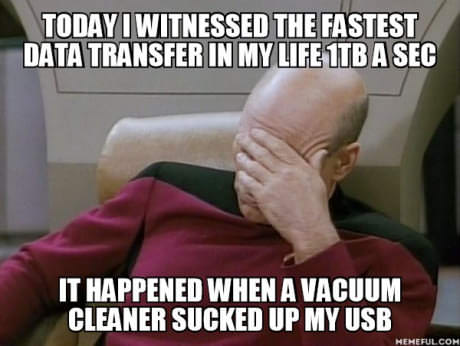

1. Imitate the worst case scenario. Run the pipeline with the '1' for the parameters below:

In [50]:
# SET UP ENV VARS
import os

os.environ['DATA_WRITER__BUFFER_MAX_ITEMS'] = '1'
os.environ['DATA_WRITER__FILE_MAX_ITEMS'] = '1'
os.environ['EXTRACT__WORKERS'] = '4'
os.environ['NORMALIZE__WORKERS'] = '4'
os.environ['LOAD__WORKERS'] = '8'

Run your REST API source pipeline:

In [51]:
pipeline = dlt.pipeline(
    pipeline_name="rest_api_anime",
    destination='duckdb',
    dataset_name="rest_api_data",
    progress="log",
)

load_info = pipeline.run(anime_source.add_limit(2))
print(load_info)
print(pipeline.last_trace)

---------------------------- Extract rest_api_anime ----------------------------
Resources: 0/1 (0.0%) | Time: 0.00s | Rate: 0.00/s
Memory usage: 427.76 MB (13.70%) | CPU usage: 0.00%

---------------------------- Extract rest_api_anime ----------------------------
Resources: 0/1 (0.0%) | Time: 0.15s | Rate: 0.00/s
anime_source: 25  | Time: 0.00s | Rate: 2330168.89/s
Memory usage: 428.09 MB (13.70%) | CPU usage: 0.00%

---------------------------- Extract rest_api_anime ----------------------------
Resources: 1/1 (100.0%) | Time: 0.29s | Rate: 3.46/s
anime_source: 50  | Time: 0.14s | Rate: 353.47/s
Memory usage: 428.23 MB (13.70%) | CPU usage: 0.00%

---------------- Normalize rest_api_anime in 1728751297.8631928 ----------------
Files: 0/2 (0.0%) | Time: 0.00s | Rate: 0.00/s
Memory usage: 428.32 MB (13.70%) | CPU usage: 0.00%

---------------- Normalize rest_api_anime in 1728751297.8631928 ----------------
Files: 0/2 (0.0%) | Time: 0.00s | Rate: 0.00/s
Items: 0  | Time: 0.00s | Rate: 

2. How long it took? Like forever?

3. Speed up the pipeline. Don't run dlt pipeline with defaults, play with parameters, find the best configuration.

## Answer the Questions:

**3.** What was the optimal number of extract, normalize and load workers?

This question is open, because you can get different results for different machines and implementations